In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/cleaned_traffic.csv")

print(df.shape)

(34451, 256)


C:\Users\vikhy\AppData\Local\Temp\ipykernel_13164\3702517407.py:1: DtypeWarning: Columns (0: Ri_MSV30maxRi_Kfz_MobisSo, 1: Ri_MSV30maxRi_Kfz_W, 2: Ri_MSV30maxRi_Kfz_U, 3: Ri_MSV30maxRi_Kfz_S, 4: DL_Q, 5: bSV30_MobisSo_Ri1, 6: bSV30_MobisSo_Ri2, 7: bSV30_W_Ri1, 8: bSV30_W_Ri2, 9: bSV30_U_Ri1, 10: bSV30_U_Ri2, 11: bSV30_S_Ri1, 12: bSV30_S_Ri2, 13: bSV50_MobisSo_Ri1, 14: bSV50_MobisSo_Ri2, 15: bLkwK50_MobisSo_Ri1, 16: bLkwK50_MobisSo_Ri2, 17: Abschnitt_Ast, 18: Station, 19: Ausrichtung) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/cleaned_traffic.csv")


In [3]:
roads = [6, 9, 93]

traffic = df[df["Str_Nr"].isin(roads)].copy()

traffic.shape

(2779, 256)

In [4]:
traffic["Str_Nr"].value_counts()

Str_Nr
9     1339
6     1177
93     263
Name: count, dtype: int64

In [ ]:
#check for missing values in traffic and year columns
traffic[
    [
        "DTV_Kfz_W_Q",
        "Jahr"
    ]
].isna().sum()

DTV_Kfz_W_Q    385
Jahr             0
dtype: int64

In [6]:
#remove records with missing traffic values
traffic = traffic.dropna(
    subset=["DTV_Kfz_W_Q"]
)

traffic.shape

(2394, 256)

In [ ]:
#average traffic by year and road
yearly = (
    traffic
    .groupby(
        ["Jahr","Str_Nr"]
    )["DTV_Kfz_W_Q"]
    .mean()
    .reset_index() #After groupby().mean(), pandas creates a MultiIndex,reset_index() converts them back into regular columns:
)

yearly.head()

,Jahr,Str_Nr,DTV_Kfz_W_Q
0,2003,6,40.741486
1,2003,9,50.959829
2,2003,93,40.662500
3,2004,6,40.735140
4,2004,9,48.178268


In [ ]:
#Pivot Table
pivot = yearly.pivot(
    index="Jahr",
    columns="Str_Nr",
    values="DTV_Kfz_W_Q"
)

pivot.head()

Str_Nr,6,9,93
Jahr,,,
2003,40.741486,50.959829,40.662500
2004,40.735140,48.178268,40.105091
2005,39.840372,48.195500,38.860545
2006,37.144581,58.402313,38.900833
2007,37.616791,60.003321,39.807000


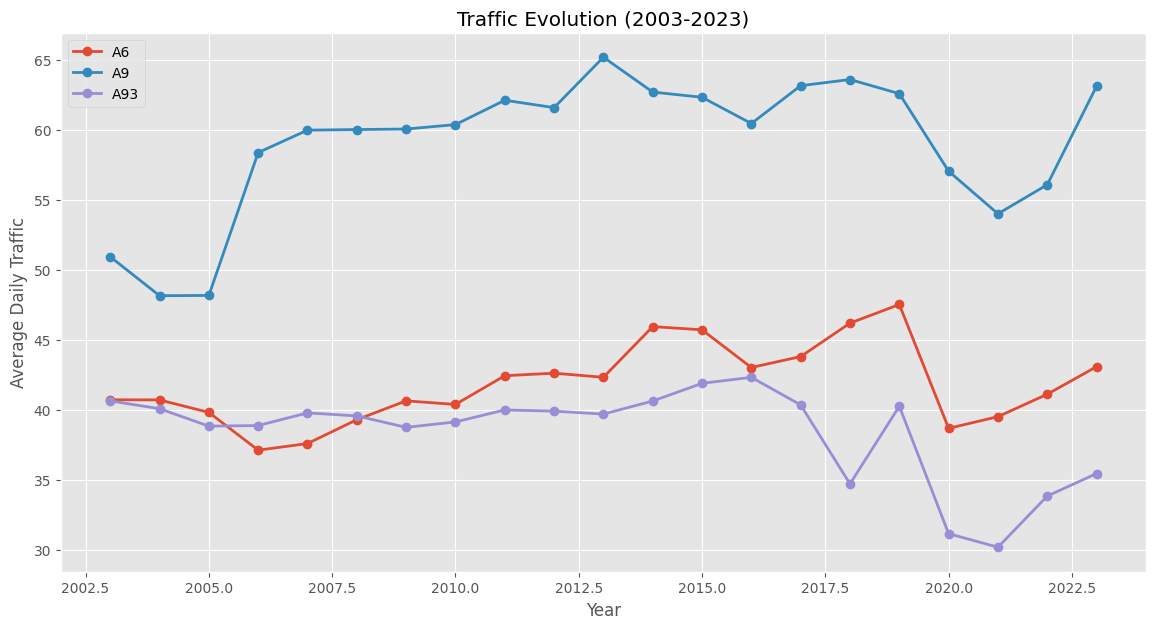

In [9]:
#Plot Evalualtion
plt.figure(figsize=(14,7))

for road in pivot.columns:

    plt.plot(
        pivot.index,
        pivot[road],
        marker="o",
        linewidth=2,
        label=f"A{road}"
    )

plt.title(
    "Traffic Evolution (2003-2023)"
)

plt.xlabel("Year")

plt.ylabel("Average Daily Traffic")

plt.legend()

plt.grid(True)

plt.show()


In [10]:
#growth Rate
growth = pivot.pct_change()*100

growth.head()

Str_Nr,6,9,93
Jahr,,,
2003,NaN,NaN,NaN
2004,-0.015577,-5.458339,-1.370819
2005,-2.196549,0.035767,-3.103211
2006,-6.766480,21.177937,0.103673
2007,1.271274,2.741344,2.329427


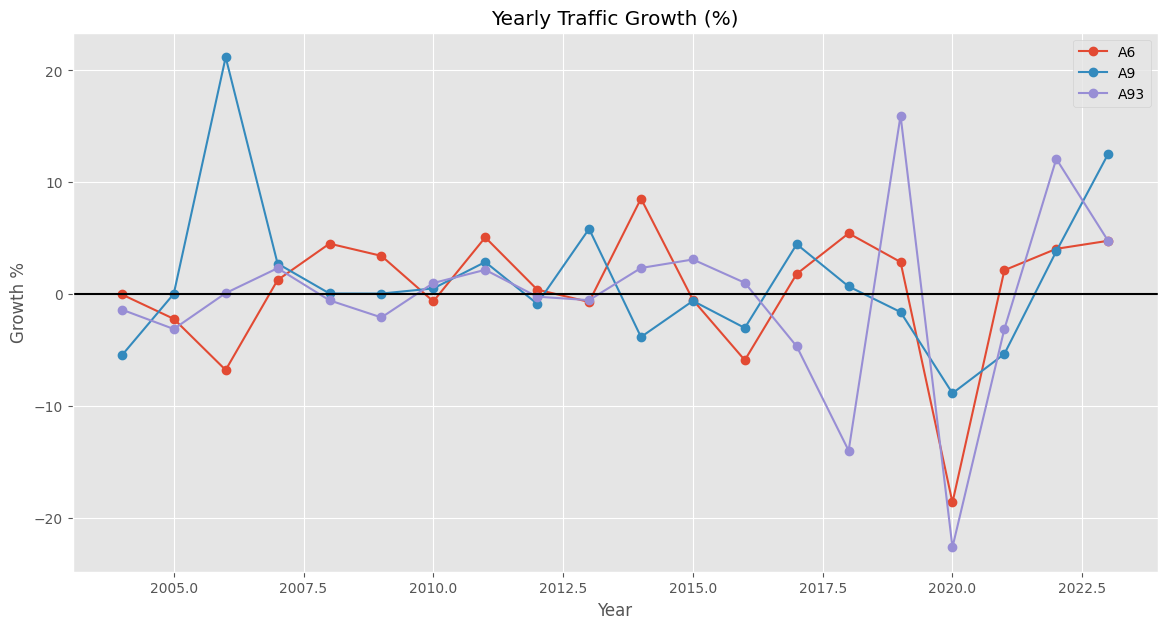

In [11]:
plt.figure(figsize=(14,7))

for road in growth.columns:

    plt.plot(
        growth.index,
        growth[road],
        marker="o",
        label=f"A{road}"
    )

plt.title(
    "Yearly Traffic Growth (%)"
)

plt.xlabel("Year")

plt.ylabel("Growth %")

plt.axhline(
    0,
    color="black"
)

plt.legend()

plt.grid(True)

plt.show()

In [13]:
#Average Traffic
average = (
    traffic
    .groupby("Str_Nr")
    ["DTV_Kfz_W_Q"]
    .mean()
)

average

Str_Nr
6     42.030973
9     59.495539
93    38.656750
Name: DTV_Kfz_W_Q, dtype: float64

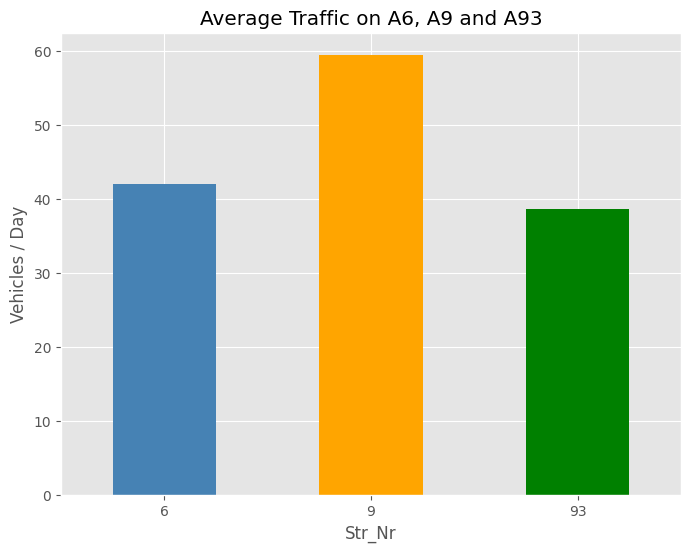

In [14]:
#Bus Chart
plt.figure(figsize=(8,6))

average.plot(
    kind="bar",
    color=["steelblue","orange","green"]
)

plt.title(
    "Average Traffic on A6, A9 and A93"
)

plt.ylabel(
    "Vehicles / Day"
)

plt.xticks(rotation=0)

plt.show()

In [15]:
#Heavy Vehicle Trend
heavy = (
    traffic
    .groupby(
        ["Jahr","Str_Nr"]
    )["DTV_SV_W_Q"]
    .mean()
    .reset_index()
)

In [16]:
heavy_pivot = heavy.pivot(
    index="Jahr",
    columns="Str_Nr",
    values="DTV_SV_W_Q"
)

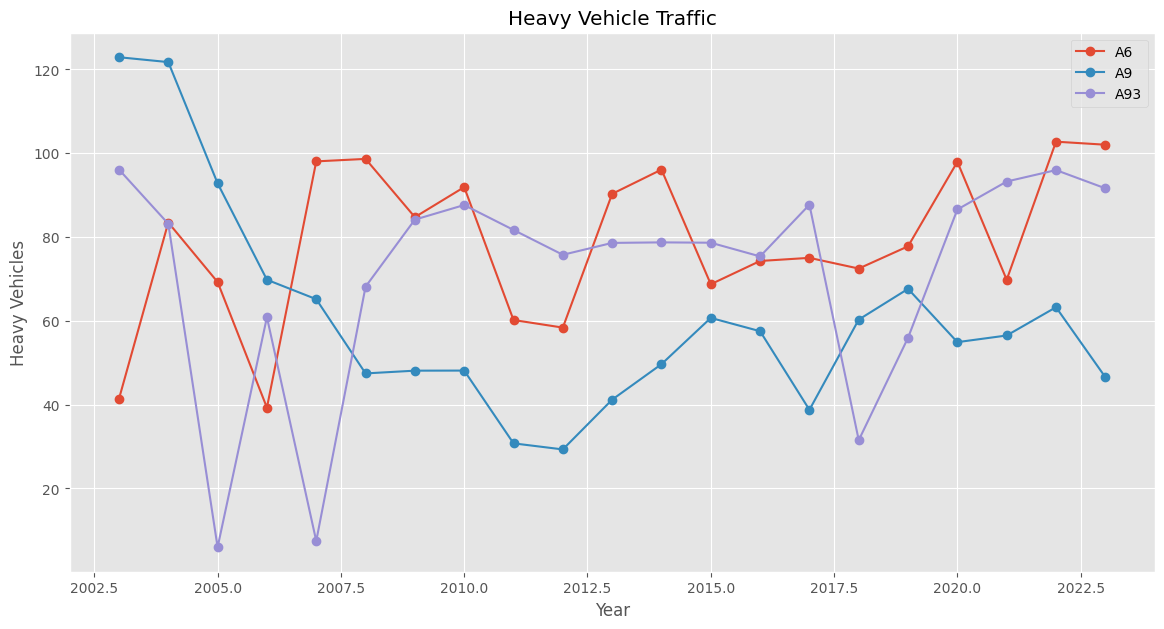

In [17]:
plt.figure(figsize=(14,7))

for road in heavy_pivot.columns:

    plt.plot(
        heavy_pivot.index,
        heavy_pivot[road],
        marker="o",
        label=f"A{road}"
    )

plt.title(
    "Heavy Vehicle Traffic"
)

plt.xlabel("Year")

plt.ylabel("Heavy Vehicles")

plt.legend()

plt.grid(True)

plt.show()

In [18]:
truck = (
    traffic
    .groupby(
        ["Jahr","Str_Nr"]
    )["pSV_W_Q"]
    .mean()
    .reset_index()
)

In [19]:
truck_pivot = truck.pivot(
    index="Jahr",
    columns="Str_Nr",
    values="pSV_W_Q"
)

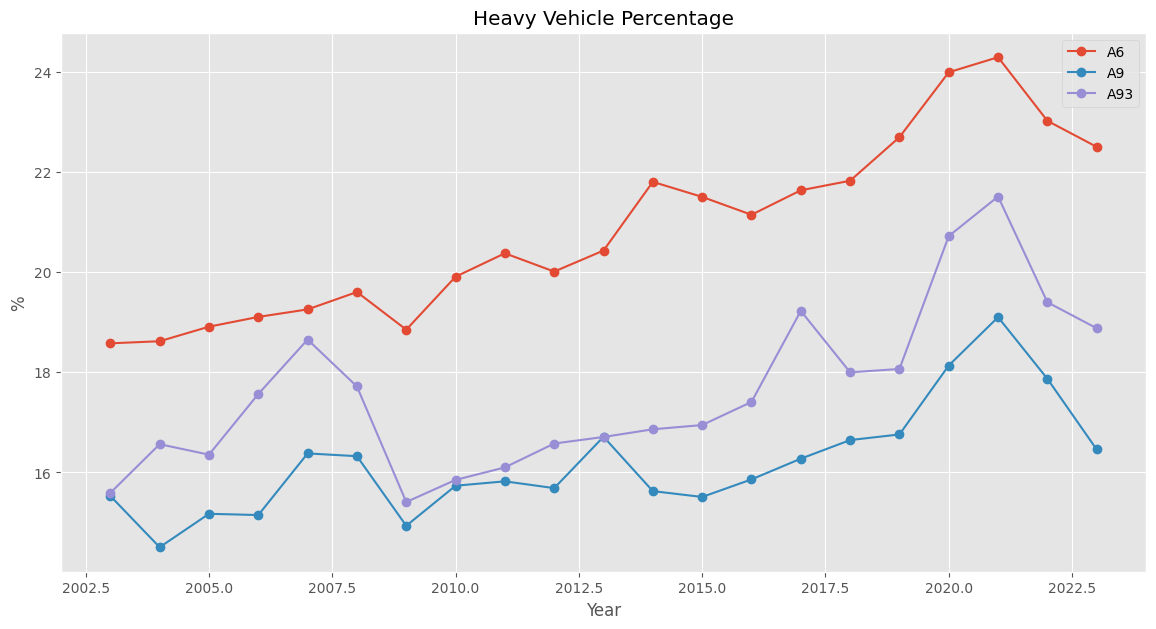

In [20]:
plt.figure(figsize=(14,7))

for road in truck_pivot.columns:

    plt.plot(
        truck_pivot.index,
        truck_pivot[road],
        marker="o",
        label=f"A{road}"
    )

plt.title(
    "Heavy Vehicle Percentage"
)

plt.ylabel("%")

plt.xlabel("Year")

plt.legend()

plt.grid(True)

plt.show()

In [22]:
#Summary Table
summary = (
    traffic
    .groupby("Str_Nr")
    .agg(
        Average_Traffic=("DTV_Kfz_W_Q","mean"),
        Maximum=("DTV_Kfz_W_Q","max"),
        Minimum=("DTV_Kfz_W_Q","min"),
        Std=("DTV_Kfz_W_Q","std")
    )
)

summary

,Average_Traffic,Maximum,Minimum,Std
Str_Nr,,,,
6,42.030973,103.735,2.478,24.445103
9,59.495539,161.527,3.320,34.919984
93,38.656750,75.655,5.374,18.813721


In [24]:
#best year
best = (
    traffic.loc[
        traffic.groupby("Str_Nr")
        ["DTV_Kfz_W_Q"]
        .idxmax()
    ]
)

best[
    [
        "Str_Nr",
        "Jahr",
        "DZ_Name",
        "DTV_Kfz_W_Q"
    ]
]

,Str_Nr,Jahr,DZ_Name,DTV_Kfz_W_Q
330,6,2023,Neckarsulm 1,103.735
19518,9,2013,AK München-Nord (N),161.527
14899,93,2016,AK Regensburg (N),75.655


In [25]:
#Lowest Year
lowest = (
    traffic.loc[
        traffic.groupby("Str_Nr")
        ["DTV_Kfz_W_Q"]
        .idxmin()
    ]
)

lowest[
    [
        "Str_Nr",
        "Jahr",
        "DZ_Name",
        "DTV_Kfz_W_Q"
    ]
]

,Str_Nr,Jahr,DZ_Name,DTV_Kfz_W_Q
24511,6,2010,Wernigerode,2.478
5593,9,2021,Oberwesel,3.320
11924,93,2018,Gardschütz,5.374


In [27]:
summary.to_csv(
    "../results/traffic_summary.csv"
)